In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import os
from sklearn.metrics import classification_report
import gc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
tf.config.threading.set_intra_op_parallelism_threads(4)
tf.config.threading.set_inter_op_parallelism_threads(4)

In [3]:
train_dir = "./data/train"
test_dir = "./data/test"

In [4]:
IMG_SIZE = 64
BATCH_SIZE = 32 
EPOCHS = 20

In [5]:
# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# Extract class names BEFORE applying ignore_errors
class_names = train_ds.class_names
num_classes = len(class_names)
print("\nClasses found:", class_names)
print(f"Number of classes: {num_classes}")

Found 19993 files belonging to 5 classes.
Found 5057 files belonging to 5 classes.

Classes found: ['galaxy', 'nebula', 'planet', 'star', 'unknown']
Number of classes: 5


In [6]:
train_ds = train_ds.ignore_errors()
test_ds = test_ds.ignore_errors()

In [7]:
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.1),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])


C:\Users\samriti\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)


Epoch 1/20
    625/Unknown 118s 174ms/step - accuracy: 0.7849 - loss: 0.5415

C:\Users\samriti\AppData\Local\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


625/625 ━━━━━━━━━━━━━━━━━━━━ 130s 193ms/step - accuracy: 0.8861 - loss: 0.3059 - val_accuracy: 0.8995 - val_loss: 0.5014
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 199ms/step - accuracy: 0.9587 - loss: 0.1190 - val_accuracy: 0.9025 - val_loss: 0.5164
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 111s 176ms/step - accuracy: 0.9682 - loss: 0.0958 - val_accuracy: 0.9237 - val_loss: 0.6197
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 112s 179ms/step - accuracy: 0.9746 - loss: 0.0741 - val_accuracy: 0.9322 - val_loss: 0.7279
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 121s 193ms/step - accuracy: 0.9783 - loss: 0.0640 - val_accuracy: 0.9326 - val_loss: 0.6955
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 223ms/step - accuracy: 0.9808 - loss: 0.0595 - val_accuracy: 0.9353 - val_loss: 0.8155
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 457s 730ms/step - accuracy: 0.9814 - loss: 0.0556 - val_accuracy: 0.9347 - val_loss: 0.8042
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 125s 198ms/step - accuracy: 0.9824 - loss: 0.04

In [11]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {round(test_acc * 100, 2)}%")

159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.9361 - loss: 1.7787

Test Accuracy: 93.61%


In [12]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(pred_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [13]:
print("Model Performance Summary:")
overall_acc = (y_true == y_pred).sum() / len(y_true)
print(f"\nOverall Accuracy: {overall_acc * 100:.2f}%")
print(f"\nTotal samples: {len(y_true)}")

for i, class_name in enumerate(class_names):
    true_mask = y_true == i
    num_samples = true_mask.sum()
    
    if num_samples > 0:
        correct = ((y_true == i) & (y_pred == i)).sum()
        accuracy = correct / num_samples * 100
        
        print(f"\n{class_name}:")
        print(f"  Samples: {num_samples}")
        print(f"  Correct: {correct}")
        print(f"  Accuracy: {accuracy:.2f}%")

gc.collect()

Model Performance Summary:

Overall Accuracy: 93.61%

Total samples: 5057

galaxy:
  Samples: 1000
  Correct: 1000
  Accuracy: 100.00%

nebula:
  Samples: 1000
  Correct: 996
  Accuracy: 99.60%

planet:
  Samples: 1000
  Correct: 796
  Accuracy: 79.60%

star:
  Samples: 1057
  Correct: 1000
  Accuracy: 94.61%

unknown:
  Samples: 1000
  Correct: 942
  Accuracy: 94.20%


2426

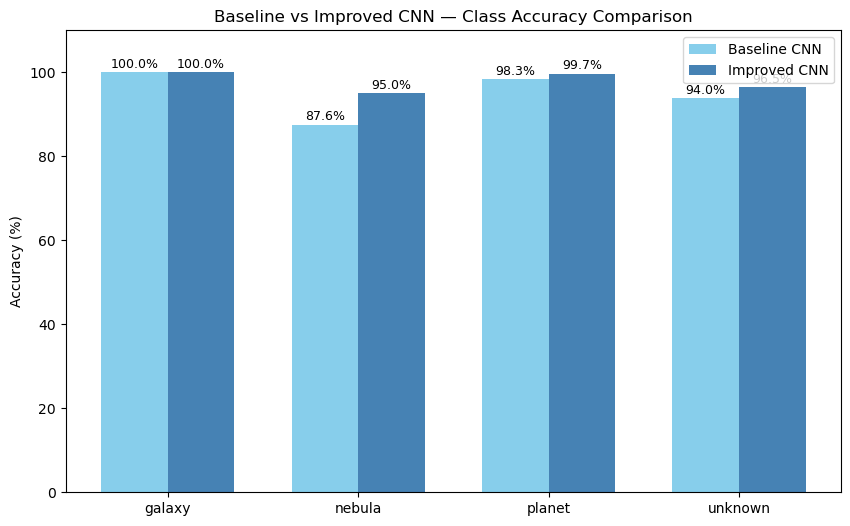

In [14]:
# Classes to show (exclude star)
classes = ["galaxy", "nebula", "planet", "unknown"]
 
# Baseline model accuracies (in %)
baseline_acc = [100.00, 87.56, 98.29, 93.95]
 
# Improved model accuracies (in %)
improved_acc = [100.00, 94.96, 99.69, 96.54]
 
x = np.arange(len(classes))  # label locations
width = 0.35                # width of each bar
 
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, baseline_acc, width, label="Baseline CNN", color="skyblue")
plt.bar(x + width/2, improved_acc, width, label="Improved CNN", color="steelblue")
 
plt.ylabel("Accuracy (%)")
plt.title("Baseline vs Improved CNN — Class Accuracy Comparison")
plt.xticks(x, classes)
plt.ylim(0, 110)
plt.legend()
 
# add value labels on top of each bar
for i, v in enumerate(baseline_acc):
    plt.text(i - width/2, v + 1, f"{v:.1f}%", ha='center', fontsize=9)
for i, v in enumerate(improved_acc):
    plt.text(i + width/2, v + 1, f"{v:.1f}%", ha='center', fontsize=9)
 
plt.show()

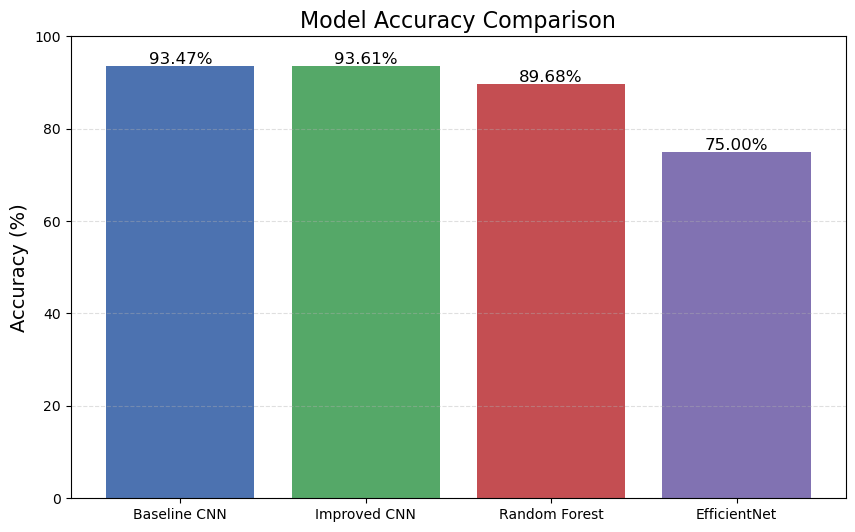

In [2]:
accuracies = {
    "Baseline CNN": 93.47,
    "Improved CNN": 93.61,
    "Random Forest": 89.68,
    "EfficientNet": 75.00
}
models = list(accuracies.keys())
values = list(accuracies.values())
plt.figure(figsize=(10,6))

bars = plt.bar(models, values, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f"{height:.2f}%", ha='center', fontsize=12)


plt.title("Model Accuracy Comparison", fontsize=16)
plt.ylabel("Accuracy (%)", fontsize=14)
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

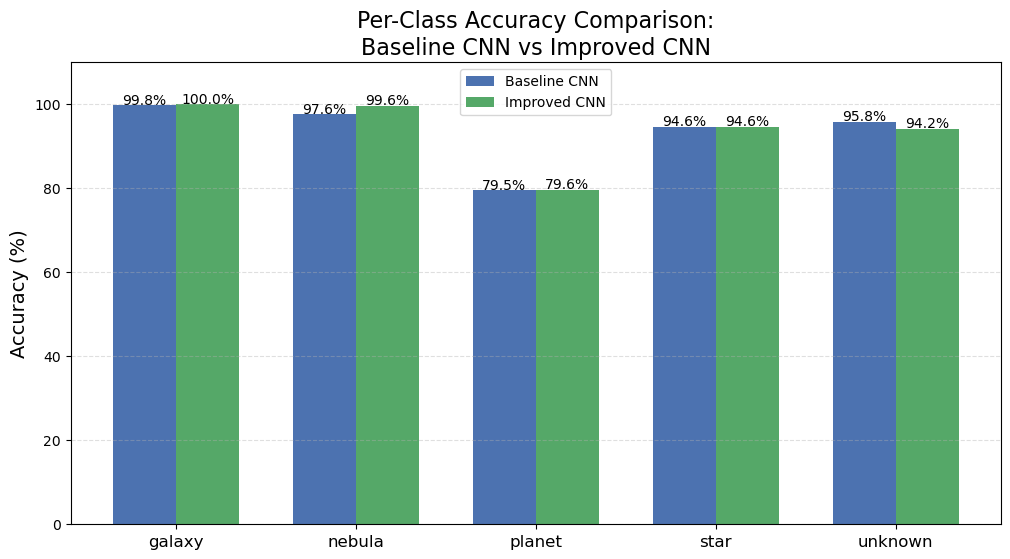

In [3]:
# class labels
classes = ["galaxy", "nebula", "planet", "star", "unknown"]
 
# accuracies
baseline = [99.80, 97.60, 79.50, 94.61, 95.80]
improved = [100.00, 99.60, 79.60, 94.61, 94.20]
 
x = np.arange(len(classes))
width = 0.35  # bar width
 
plt.figure(figsize=(12,6))
 
plt.bar(x - width/2, baseline, width, label="Baseline CNN", color="#4C72B0")
plt.bar(x + width/2, improved, width, label="Improved CNN", color="#55A868")
 
# add labels on top of each bar
for i, v in enumerate(baseline):
    plt.text(i - width/2, v + 0.3, f"{v:.1f}%", ha="center", fontsize=10)
 
for i, v in enumerate(improved):
    plt.text(i + width/2, v + 0.3, f"{v:.1f}%", ha="center", fontsize=10)
 
plt.xticks(x, classes, fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=14)
plt.title("Per-Class Accuracy Comparison:\nBaseline CNN vs Improved CNN", fontsize=16)
 
plt.ylim(0, 110)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
 
plt.show()

In [15]:
os.makedirs("results", exist_ok=True)

with open("results/model_performance.txt", "w") as f:
    f.write("MODEL PERFORMANCE\n")
    f.write(f"Test Accuracy: {round(test_acc * 100, 2)}%\n")
    f.write(f"Test Loss: {round(test_loss, 4)}\n\n")
    
    f.write("Classes:\n")
    for i, c in enumerate(class_names):
        f.write(f"  {i}: {c}\n")
    
    f.write("\n" + "=" * 60 + "\n")
    f.write("PER-CLASS PERFORMANCE\n")
    f.write("=" * 60 + "\n\n")
    
    for i, class_name in enumerate(class_names):
        class_mask = y_true == i
        if class_mask.sum() > 0:
            correct = ((y_true == i) & (y_pred == i)).sum()
            total = class_mask.sum()
            accuracy = correct / total * 100
            f.write(f"{class_name}:\n")
            f.write(f"  Samples: {total}\n")
            f.write(f"  Correct: {correct}\n")
            f.write(f"  Accuracy: {accuracy:.2f}%\n\n")
    
    f.write("CONFIGURATION\n")
    f.write(f"Image Size: {IMG_SIZE}x{IMG_SIZE}\n")
    f.write(f"Batch Size: {BATCH_SIZE}\n")
    f.write(f"Epochs: {EPOCHS}\n")

print("Performance report saved")

Performance report saved


In [16]:
model.save("results/model.h5")
print("Model saved")

gc.collect()

Model saved


3553